# SVM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              classification_report, confusion_matrix,
                              roc_curve, auc)

print("Libraries imported! ✅")

Libraries imported! ✅


In [2]:
#Load Iris (perfect for SVM visualization)
df = pd.read_csv(r"C:\Users\MINHAJ\Downloads\Data Set For Task-20260408T161732Z-3-001\Data Set For Task\1) iris.csv")

# Encode target
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

# Use only 2 features for decision boundary visualization
X = df[['petal_length', 'petal_width']].values
y = df['species_encoded'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Data ready! ✅")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Data ready! ✅
Training samples: 120
Testing samples: 30


In [3]:
#  Train TWO models: Linear vs RBF kernel
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)
pred_rbf = svm_rbf.predict(X_test)

print("=" * 45)
print("       KERNEL COMPARISON RESULTS")
print("=" * 45)
print(f"Linear Kernel Accuracy:  {accuracy_score(y_test, pred_linear):.2%}")
print(f"RBF Kernel Accuracy:     {accuracy_score(y_test, pred_rbf):.2%}")
print("=" * 45)
print("\nLinear Kernel Report:")
print(classification_report(y_test, pred_linear, target_names=le.classes_))

       KERNEL COMPARISON RESULTS
Linear Kernel Accuracy:  100.00%
RBF Kernel Accuracy:     100.00%

Linear Kernel Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



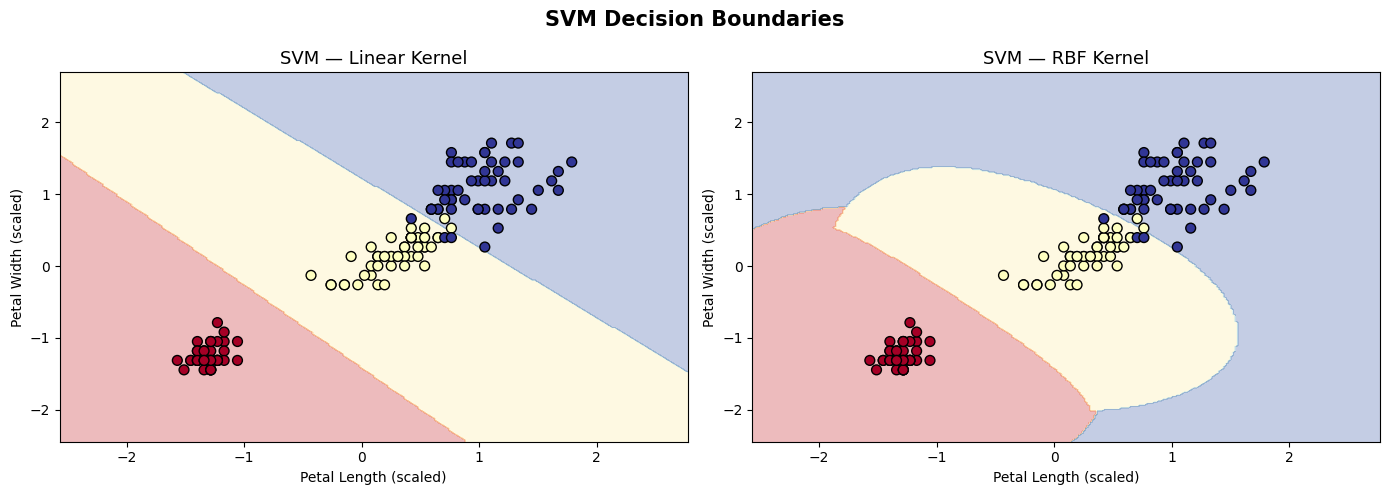

Decision boundaries plotted! ✅


In [5]:
#  — Visualize Decision Boundaries (the coolest plot in ML!)
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, 
                         cmap='RdYlBu', edgecolors='black', s=50)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Petal Length (scaled)")
    ax.set_ylabel("Petal Width (scaled)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_scaled, y, 
                       "SVM — Linear Kernel", axes[0])
plot_decision_boundary(svm_rbf, X_scaled, y, 
                       "SVM — RBF Kernel", axes[1])
plt.suptitle("SVM Decision Boundaries", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("svm_decision_boundaries.png")
plt.show()
print("Decision boundaries plotted! ✅")

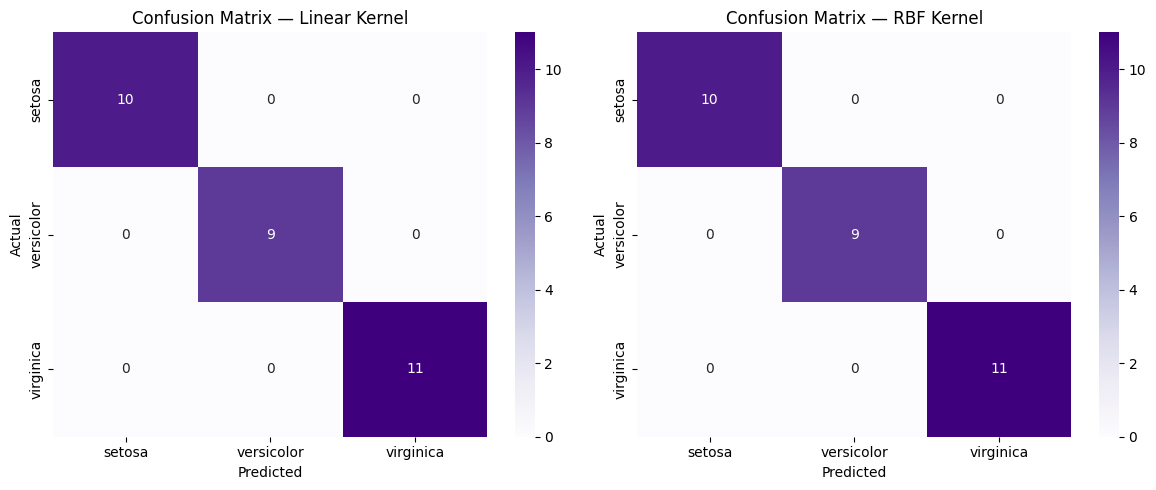


🎓 ALL 6 TASKS COMPLETE! INTERNSHIP DONE! 🎉


In [6]:
# Cell 5 — Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(axes, 
                            [pred_linear, pred_rbf],
                            ['Linear Kernel', 'RBF Kernel']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig("svm_confusion_matrices.png")
plt.show()

print("\n🎓 ALL 6 TASKS COMPLETE! INTERNSHIP DONE! 🎉")